<a href="https://colab.research.google.com/github/swanpyaesone163-dev/biogasResearch/blob/main/heat_stress_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heat Stress Alerting Simulation — Mohali District, Punjab, India (2022)

**v2 changes from the previous notebook:**
- The binary 95th-percentile detection system has been superseded by a three-tier
  **Yellow / Orange / Red** severity classification sourced from UPSDMA (Uttar Pradesh State
  Disaster Management Authority).
- For raw air temperature ($T_a$), the UPSDMA-published absolute values for **Ludhiana, Punjab**
  are used directly — these are *pre-computed* 75th/85th/95th-percentile crossings of historical
  climatological data, so no derivation is needed for that pipeline.
- For HI and ESI (which UPSDMA does not publish thresholds for), equivalent tier thresholds are
  **derived** by computing the 75th/85th/95th percentile of each index's own baseline distribution
  — the same percentile basis UPSDMA used for $T_a$, kept methodologically consistent.
- Dispatch/vulnerability-segment channel logic is unchanged and is **not** tier-differentiated —
  per current scope, severity classification is the analytical focus; dispatch is included only
  nominally.

**Limitation carried over from the paper:** Ludhiana is used as a station proxy for Mohali District
because UPSDMA does not publish Mohali-specific thresholds. This proxy is a known limitation,
flagged here and in the manuscript rather than glossed over.

## 1. Install dependencies
Run once per Colab session.

In [2]:
!pip install cfgrib xarray eccodes --quiet
# cfgrib needs the eccodes C library underneath. If the import in the next cells
# fails with "eccodes library not found", uncomment the line below and re-run:
# !apt-get install -y libeccodes0 libeccodes-dev --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 48.0 MB/s eta 0:00:00


In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

warnings.filterwarnings("ignore")

## 2. Constants

In [4]:
# Mohali District bounding box (lat/lon)
LAT_MIN, LAT_MAX = 30.60, 30.85
LON_MIN, LON_MAX = 76.65, 76.95

# Number of simulated sensor nodes
N_NODES = 25

# UHI offset range (uniform distribution, degrees C)
UHI_MIN, UHI_MAX = 0.0, 2.5

# Forecast trigger threshold for dual-mode switching (IMD plains criterion)
FORECAST_DEPARTURE_THRESHOLD = 4.5  # degrees C above ERA5 climatological normal

# --- UPSDMA three-tier severity classification -----------------------------
# UPSDMA-published absolute T_a thresholds for Ludhiana, Punjab.
# Ludhiana is used as a station proxy for Mohali District (UPSDMA does not
# publish Mohali-specific values) -- this proxy is a known, disclosed
# limitation, not an assumption made silently.
UPSDMA_TA_THRESHOLDS = {
    "Yellow": 37.62,
    "Orange": 40.39,
    "Red":    43.83,
}

# UPSDMA's T_a values are themselves pre-computed crossings of these
# percentiles of historical climatological data. The same percentiles are
# used below to derive equivalent HI/ESI thresholds, keeping the approach
# methodologically consistent across all three pipelines.
TIER_PERCENTILES = {"Yellow": 75, "Orange": 85, "Red": 95}

SEVERITY_RANK = {"None": 0, "Yellow": 1, "Orange": 2, "Red": 3}
RANK_TO_SEVERITY = {v: k for k, v in SEVERITY_RANK.items()}

TIER_COLOURS = {
    "None":   "#d9d9d9",
    "Yellow": "#f1c400",
    "Orange": "#e67e22",
    "Red":    "#c0392b",
}
TIER_PLOT_ORDER = ["None", "Yellow", "Orange", "Red"]

# Vulnerability segment proportions (Punjab demographics) -- included
# nominally for context; not used to differentiate dispatch logic, since
# the analytical focus here is severity classification, not dispatch.
SEGMENTS = {
    "Elderly (60+)":          0.115,
    "Outdoor Workers":        0.392,
    "Children (<15)":         0.192,
    "General Population":     0.301,  # residual
}
TOTAL_POP = 10_000
APP_REGISTRATION_RATE = 0.45  # fraction with smartphones/app

# Monte Carlo parameters
MC_ITERATIONS = 1_000

# Network condition parameters: (packet_loss_prob, latency_mean_s, latency_std_s)
NETWORK_CONDITIONS = {
    "Stable 4G": (0.05,  1.5,  0.5),
    "Degraded 2G": (0.30, 10.0, 5.0),
}
SMS_PARAMS = (0.00, 60.0, 10.0)   # SMS: 0% loss, independent of data network

# Channel base infrastructure reliability (independent of network)
CHANNEL_RELIABILITY = {
    "App Push":   0.97,
    "News Feed":  0.99,
    "Radio Feed": 0.99,
    "SMS":        0.98,
}

# Simulation period -- now spans the full calendar year so the dual-mode
# sensor's annual operating profile (Results 2/3) can be characterized
# through the genuine low-risk season, not just the pre-monsoon/monsoon
# window.
SIM_START = "2022-01-01"
SIM_END   = "2022-12-31"

# Heat-relevant window used for Result 1 (severity-tier headline stats).
# Kept separate from SIM_START/SIM_END so alert percentages aren't
# diluted by months where heat risk is negligible by construction.
HEAT_SEASON_START = "2022-01-01"
HEAT_SEASON_END   = "2022-09-30"

## 3. Data loading
`load_era5_grib` reads a real ERA5 GRIB file; `generate_synthetic_era5` is the fallback used when no file is supplied (now also used to stand in for the 1991–2020 baseline used to derive HI/ESI tier thresholds).

In [17]:
def load_era5_grib(grib_path: str, apply_sim_slice: bool = True) -> pd.DataFrame:
    """Load ERA5 GRIB file with better error handling and diagnostics."""
    try:
        import cfgrib
        import xarray as xr
    except ImportError:
        raise ImportError("cfgrib and xarray required. Run install cell first.")

    print(f"  Loading GRIB: {grib_path}")
    try:
        ds = xr.open_dataset(grib_path, engine="cfgrib",
                             backend_kwargs={'filter_by_keys': {'stepType': 'instant'}})
        print(f"  Variables in file (primary load): {list(ds.data_vars)}")
    except Exception as e:
        print(f"  Error opening GRIB: {e}")
        print("  Falling back to synthetic data.")
        return generate_synthetic_era5()

    df = pd.DataFrame()

    for var_name, col in [("t2m", "T_a"), ("d2m", "Td")]:
        if var_name in ds.data_vars:
            try:
                da = ds[var_name]
                if "latitude" in da.dims and "longitude" in da.dims:
                    da = da.sel(latitude=slice(LAT_MAX, LAT_MIN),
                                longitude=slice(LON_MIN, LON_MAX)).mean(dim=["latitude", "longitude"])
                elif "lat" in da.dims and "lon" in da.dims:
                    da = da.sel(lat=slice(LAT_MIN, LAT_MAX),
                                lon=slice(LON_MIN, LON_MAX)).mean(dim=["lat", "lon"])
                df[col] = da.values - 273.15
                print(f"  Loaded {col} from '{var_name}'")
            except Exception as e:
                print(f"    Could not load {var_name}: {e}")

    if "time" in ds.coords:
        df.index = pd.to_datetime(ds["time"].values)
    else:
        print("  Warning: no time coordinate found, using default range.")
        df.index = pd.date_range(SIM_START, periods=len(df), freq="h")
    df.index.name = "time"

    # ---- SSRD: forecast-accumulated, needs its own (ref_time, step) handling ----
    try:
        ssrd_series = _load_ssrd_series(grib_path)
        df["SSRD"] = ssrd_series.reindex(df.index)
        n_missing = int(df["SSRD"].isna().sum())
        if n_missing:
            print(f"  SSRD: interpolating {n_missing} missing hour(s)")
            df["SSRD"] = df["SSRD"].interpolate(limit_direction="both")
        n_still_missing = int(df["SSRD"].isna().sum())
        if n_still_missing:
            print(f"  Warning: {n_still_missing} hour(s) still missing SSRD, using 200 W/m^2 fallback")
            df["SSRD"] = df["SSRD"].fillna(200.0)
        print(f"  Loaded SSRD: mean={df['SSRD'].mean():.1f} W/m^2, max={df['SSRD'].max():.1f} W/m^2")
    except Exception as e:
        print(f"  Could not load SSRD ({e}), using default 200 W/m^2")
        df["SSRD"] = 200.0

    if "T_a" not in df.columns or "Td" not in df.columns:
        print("  Error: missing T_a or Td -- falling back to synthetic data.")
        return generate_synthetic_era5()

    df = df.dropna(subset=["T_a", "Td"]).sort_index()
    if apply_sim_slice:
        df = df.loc[SIM_START:SIM_END]

    print(f"  Loaded {len(df):,} records ({df.index[0]} to {df.index[-1]})")
    return df


def _load_ssrd_series(grib_path: str) -> pd.Series:
    """
    Load and correctly de-accumulate ERA5 SSRD (paramId 169).

    ERA5 ssrd is accumulated since the start of each forecast run, and runs
    are initialised every 12 hours, so a single xr.open_dataset() call on
    paramId 169 cannot build one rectangular hypercube and raises a
    DatasetBuildError. cfgrib.open_datasets() splits the file into separate
    consistent (reference_time, step) groups instead.

    Within each group, de-accumulation is done per forecast run only
    (diffing across a 12h reset would otherwise create spurious negative
    jumps, clipped to zero, twice a day). Each value is then converted from
    accumulated J/m^2 to a W/m^2 rate and stamped with its true
    valid_time = reference_time + step.
    """
    import cfgrib

    datasets = cfgrib.open_datasets(
        grib_path,
        backend_kwargs={"filter_by_keys": {"paramId": 169}, "indexpath": ""},
    )

    series_parts = []
    for ds in datasets:
        if "ssrd" not in ds.data_vars:
            continue

        da = ds["ssrd"]
        if "latitude" in da.dims and "longitude" in da.dims:
            da = da.sel(latitude=slice(LAT_MAX, LAT_MIN),
                        longitude=slice(LON_MIN, LON_MAX)).mean(dim=["latitude", "longitude"])
        elif "lat" in da.dims and "lon" in da.dims:
            da = da.sel(lat=slice(LAT_MIN, LAT_MAX),
                        lon=slice(LON_MIN, LON_MAX)).mean(dim=["lat", "lon"])

        if "step" not in da.dims:
            valid_time = pd.to_datetime(np.atleast_1d(da["time"].values))
            series_parts.append(pd.Series(np.clip(da.values, 0, None) / 3600.0, index=valid_time))
            continue

        ref_times = pd.to_datetime(np.atleast_1d(da["time"].values))
        step_vals = da["step"].values
        steps = pd.to_timedelta(step_vals) if np.issubdtype(step_vals.dtype, np.timedelta64) \
            else pd.to_timedelta(step_vals, unit="h")
        step_hours = steps.total_seconds() / 3600.0
        period_h = np.diff(step_hours, prepend=0.0)
        period_h[period_h <= 0] = step_hours[0] if step_hours[0] > 0 else 1.0

        for i, ref_time in enumerate(ref_times):
            run_vals = da.isel(time=i).values if "time" in da.dims else da.values
            run_vals = np.atleast_1d(run_vals)
            deaccum = np.clip(np.diff(run_vals, prepend=0.0), 0, None)
            rate = deaccum / (period_h * 3600.0)
            series_parts.append(pd.Series(rate, index=ref_time + steps))

    if not series_parts:
        raise RuntimeError("No 'ssrd' variable found in any cfgrib hypercube (paramId 169).")

    ssrd = pd.concat(series_parts).sort_index()
    return ssrd[~ssrd.index.duplicated(keep="first")]

In [6]:
import xarray as xr

ds_check = xr.open_dataset(
    GRIB_PATH, engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"paramId": 169}}  # 169 = ssrd in ECMWF table 128
)
print(list(ds_check.data_vars))

ds_all = xr.open_dataset(GRIB_PATH, engine="cfgrib")
print("Unfiltered data_vars:", list(ds_all.data_vars))

['ssrd']


ERROR:cfgrib.dataset:skipping variable: paramId==169 shortName='ssrd'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1640995200, 1640998800, 1641002400, ..., 1672520400, 1672524000,
       1672527600])) new_value=Variable(dimensions=('time',), data=array([1640973600, 1641016800, 1641060000, 1641103200, 1641146400,
       1641189600, 1641232800, 1641276000, 1641319200, 1641362400,
       1641405600, 1641448800, 1641492000, 1641535200, 1641578400,
       1641621600, 1641664800, 1641708000, 1641751200, 1641794400,
       1641837600, 1641880800, 1641924000, 1641967200, 1642010400,
       1642053600, 1642096800

Unfiltered data_vars: ['d2m', 't2m']


## 4. Get the ERA5 GRIB file (optional)

Run this cell to upload a real ERA5 GRIB file from your computer. Click **Cancel** in the upload
dialog (or just don't select a file) to skip and use synthetic data instead.

If your file lives on Google Drive instead, mount Drive and set `GRIB_PATH` to that path —
see the commented-out lines below.

In [5]:
from google.colab import files

GRIB_PATH = None  # will be set if a file is uploaded below

try:
    uploaded = files.upload()
    if uploaded:
        GRIB_PATH = list(uploaded.keys())[0]
        print(f"Using uploaded file: {GRIB_PATH}")
        print("Upload Jan-Jun baseline GRIB:")
        uploaded = files.upload()
        BASELINE_JAN_JUN_PATH = list(uploaded.keys())[0] if uploaded else None

        print("Upload Jul-Dec baseline GRIB:")
        uploaded = files.upload()
        BASELINE_JUL_DEC_PATH = list(uploaded.keys())[0] if uploaded else None
    else:
        print("No file selected — will use synthetic data.")
except Exception as e:
    print(f"Upload skipped/failed ({e}) — will use synthetic data.")

# --- Alternative: Google Drive ---
# from google.colab import drive
# drive.mount('/content/drive')
# GRIB_PATH = "/content/drive/MyDrive/path/to/era5_2022.grib"

OUT_DIR = Path("/content/heat_stress_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

Saving Mohali2022New.grib to Mohali2022New.grib
Using uploaded file: Mohali2022New.grib
Upload Jan-Jun baseline GRIB:


Saving 19991_to_2020.grib to 19991_to_2020.grib
Upload Jul-Dec baseline GRIB:


Saving 19991_to_2020_two.grib to 19991_to_2020_two.grib


In [ ]:
import cfgrib

datasets = cfgrib.open_datasets(GRIB_PATH, backend_kwargs={"filter_by_keys": {"paramId": 169}})
print(f"{len(datasets)} consistent hypercube(s) found for paramId 169:\n")
for i, ds in enumerate(datasets):
    print(f"--- hypercube {i} ---")
    print("  vars:", list(ds.data_vars))
    print("  dims:", dict(ds.dims))
    if "time" in ds.coords:
        print("  time:", ds["time"].values[:3], "...", ds["time"].values[-3:])
    if "step" in ds.coords:
        print("  step:", ds["step"].values)

1 consistent hypercube(s) found for paramId 169:

--- hypercube 0 ---
  vars: ['ssrd']
  dims: {'time': 731, 'step': 12, 'latitude': 3, 'longitude': 3}
  time: ['2021-12-31T18:00:00.000000000' '2022-01-01T06:00:00.000000000'
 '2022-01-01T18:00:00.000000000'] ... ['2022-12-30T18:00:00.000000000' '2022-12-31T06:00:00.000000000'
 '2022-12-31T18:00:00.000000000']
  step: [ 3600000000000  7200000000000 10800000000000 14400000000000
 18000000000000 21600000000000 25200000000000 28800000000000
 32400000000000 36000000000000 39600000000000 43200000000000]


## 5. Yellow / Orange / Red tier thresholds (UPSDMA framework)

$T_a$ uses UPSDMA's published absolute values directly. HI and ESI have no UPSDMA-published
equivalent, so their tier thresholds are **derived** from the 75th/85th/95th percentile of each
index's own baseline distribution — the same percentile basis UPSDMA used for $T_a$.

In [10]:
# ============================================================
# PLACEHOLDER -- REPLACE WITH REAL ERA5 1991-2020 BASELINE DATA
# ============================================================
#
# T_a: NOT derived here. UPSDMA_TA_THRESHOLDS above are already the
# published absolute Yellow/Orange/Red values for Ludhiana, Punjab (the
# Mohali proxy station), and UPSDMA states these already correspond to
# the 75th/85th/95th percentile of that station's historical climatology
# -- so no recomputation is needed or appropriate for this pipeline.
#
# HI / ESI: derived here as the 75th/85th/95th percentile of daily-maximum
# HI and ESI over a full baseline climatological year. This keeps the
# derivation methodologically consistent with how UPSDMA derived the T_a
# values, even though no UPSDMA HI/ESI thresholds exist to source directly.
#
# When real ERA5 1991-2020 data is available, replace the synthetic
# baseline call below with the real thing:
#   1. Load the full 1991-2020 hourly GRIB file for Mohali (load_era5_grib).
#   2. Compute HI and ESI at each hour (compute_indices, defined in the
#      next section).
#   3. Resample to daily max.
#   4. Compute np.percentile(daily_max, [75, 85, 95]) over the full
#      1991-2020 record -- NOT windowed by day-of-year, to stay consistent
#      with UPSDMA's single fixed-value-per-tier approach for T_a.
# ============================================================

def compute_baseline_tier_thresholds(baseline_idx_df: pd.DataFrame = None) -> dict:
    """
    T_a: UPSDMA published absolute values (unchanged).
    HI/ESI: 75th/85th/95th percentile of daily-max HI/ESI over the real
    1991-2020 ERA5 baseline (Mohali District, 11:30-17:30 local window),
    when provided. Falls back to the synthetic placeholder only if no
    real baseline is available.
    """
    thresholds = {"T_a": dict(UPSDMA_TA_THRESHOLDS)}

    if baseline_idx_df is not None:
        baseline_idx = baseline_idx_df
    else:
        baseline_raw = generate_synthetic_era5(start="2000-01-01", end="2000-12-31", seed=123)
        baseline_idx = compute_indices(baseline_raw)

    daily_max = baseline_idx.resample("D").max()
    for index_name in ["HI", "ESI"]:
        vals = daily_max[index_name].dropna().values
        thresholds[index_name] = {
            tier: round(float(np.percentile(vals, pct)), 2)
            for tier, pct in TIER_PERCENTILES.items()
        }
    return thresholds

## 6. Heat stress index computation

In [8]:
def relative_humidity_from_dewpoint(T_a: np.ndarray, Td: np.ndarray) -> np.ndarray:
    """Magnus approximation. Lawrence (2005), BAMS 86(2):225-234."""
    a, b = 17.625, 243.04
    gamma_T  = a * T_a / (b + T_a)
    gamma_Td = a * Td / (b + Td)
    RH = 100.0 * np.exp(gamma_Td - gamma_T)
    return np.clip(RH, 0.0, 100.0)


def compute_heat_index(T_a: np.ndarray, RH: np.ndarray) -> np.ndarray:
    """Rothfusz (1990) Heat Index regression, with Steadman simple formula
    below 27 degC. Inputs in degC; output in degC."""
    T_f = T_a * 9.0 / 5.0 + 32.0

    hi_simple = 0.5 * (T_f + 61.0 + (T_f - 68.0) * 1.2 + RH * 0.094)

    hi_full = (
        -42.379
        + 2.04901523 * T_f
        + 10.14333127 * RH
        - 0.22475541 * T_f * RH
        - 6.83783e-3 * T_f**2
        - 5.481717e-2 * RH**2
        + 1.22874e-3 * T_f**2 * RH
        + 8.5282e-4 * T_f * RH**2
        - 1.99e-6 * T_f**2 * RH**2
    )

    adj_low_rh  = ((13.0 - RH) / 4.0) * np.sqrt((17.0 - np.abs(T_f - 95.0)) / 17.0)
    adj_high_rh = (RH - 85.0) / 10.0 * ((87.0 - T_f) / 5.0)

    hi_full = np.where((RH < 13) & (T_f >= 80) & (T_f <= 112), hi_full - adj_low_rh, hi_full)
    hi_full = np.where((RH > 85) & (T_f >= 80) & (T_f <= 87), hi_full + adj_high_rh, hi_full)

    hi_f = np.where(T_a >= 27.0, hi_full, hi_simple)
    hi_c = (hi_f - 32.0) * 5.0 / 9.0
    return hi_c


def compute_esi(T_a: np.ndarray, RH: np.ndarray, SSRD: np.ndarray) -> np.ndarray:
    """Environmental Stress Index. Moran et al. (2001), J. Thermal Biology 26:427-431."""
    ESI = (
        0.63 * T_a
        - 0.03 * RH
        + 0.002 * SSRD
        + 0.01 * T_a * RH
        - 0.073 / (0.1 + SSRD)
        - 3.0
    )
    return ESI


def compute_indices(df: pd.DataFrame) -> pd.DataFrame:
    """Add RH, HI, and ESI columns to the DataFrame."""
    df = df.copy()
    df["RH"]  = relative_humidity_from_dewpoint(df["T_a"].values, df["Td"].values)
    df["HI"]  = compute_heat_index(df["T_a"].values, df["RH"].values)
    df["ESI"] = compute_esi(df["T_a"].values, df["RH"].values, df["SSRD"].values)
    return df

## 7. Sensor node simulation (UHI offsets) and severity classification

In [9]:
def simulate_nodes(df: pd.DataFrame, seed: int = 0) -> pd.DataFrame:
    """
    Simulate 25 sensor nodes by applying per-node UHI offsets drawn from
    U(0.0, 2.5) degC to T_a, then recomputing indices.

    Returns a DataFrame with the district-level maximum index value
    at each timestamp (the value that drives severity classification).
    """
    rng = np.random.default_rng(seed)
    uhi_offsets = rng.uniform(UHI_MIN, UHI_MAX, N_NODES)

    node_hi  = np.zeros((len(df), N_NODES))
    node_esi = np.zeros((len(df), N_NODES))
    node_ta  = np.zeros((len(df), N_NODES))

    for i, offset in enumerate(uhi_offsets):
        T_node = df["T_a"].values + offset
        RH_node = relative_humidity_from_dewpoint(T_node, df["Td"].values)
        node_hi[:, i]  = compute_heat_index(T_node, RH_node)
        node_esi[:, i] = compute_esi(T_node, RH_node, df["SSRD"].values)
        node_ta[:, i]  = T_node

    result = df.copy()
    result["HI_max"]  = node_hi.max(axis=1)
    result["ESI_max"] = node_esi.max(axis=1)
    result["Ta_max"]  = node_ta.max(axis=1)
    return result


def classify_severity(values: np.ndarray, tiers: dict) -> np.ndarray:
    """
    Classify each value into None(0)/Yellow(1)/Orange(2)/Red(3) given a
    tier dict {"Yellow": v, "Orange": v, "Red": v} with v ascending.
    Returns integer severity ranks (see SEVERITY_RANK).
    """
    rank = np.zeros(values.shape, dtype=int)
    rank[values >= tiers["Yellow"]] = SEVERITY_RANK["Yellow"]
    rank[values >= tiers["Orange"]] = SEVERITY_RANK["Orange"]
    rank[values >= tiers["Red"]]    = SEVERITY_RANK["Red"]
    return rank


def detect_severity_tiers(df: pd.DataFrame, tier_thresholds: dict) -> pd.DataFrame:
    """
    Classify hourly district-level index maxima into severity tiers for
    each of the three pipelines (HI, ESI, T_a). District-level value at
    each timestamp is already the max across all 25 nodes (from
    simulate_nodes), so a localised extreme at any single node drives a
    district-wide tier rather than being masked by spatial averaging.
    """
    df = df.copy()
    for index_name, col in [("HI", "HI_max"), ("ESI", "ESI_max"), ("T_a", "Ta_max")]:
        rank = classify_severity(df[col].values, tier_thresholds[index_name])
        df[f"severity_rank_{index_name}"] = rank
        df[f"severity_{index_name}"] = [RANK_TO_SEVERITY[r] for r in rank]
    return df


def daily_peak_severity(df: pd.DataFrame, index_name: str) -> pd.Series:
    """Daily peak severity tier (the worst tier reached that day)."""
    rank_col = f"severity_rank_{index_name}"
    daily_rank = df[rank_col].resample("D").max()
    return daily_rank.map(RANK_TO_SEVERITY)

In [11]:
def simulate_nodes(df: pd.DataFrame, seed: int = 0) -> pd.DataFrame:
    """
    Simulate 25 sensor nodes by applying per-node UHI offsets drawn from
    U(0.0, 2.5) degC to T_a, then recomputing indices.

    Returns a DataFrame with the district-level maximum index value
    at each timestamp (the value that drives severity classification).
    """
    rng = np.random.default_rng(seed)
    uhi_offsets = rng.uniform(UHI_MIN, UHI_MAX, N_NODES)

    node_hi  = np.zeros((len(df), N_NODES))
    node_esi = np.zeros((len(df), N_NODES))
    node_ta  = np.zeros((len(df), N_NODES))

    for i, offset in enumerate(uhi_offsets):
        T_node = df["T_a"].values + offset
        RH_node = relative_humidity_from_dewpoint(T_node, df["Td"].values)
        node_hi[:, i]  = compute_heat_index(T_node, RH_node)
        node_esi[:, i] = compute_esi(T_node, RH_node, df["SSRD"].values)
        node_ta[:, i]  = T_node

    result = df.copy()
    result["HI_max"]  = node_hi.max(axis=1)
    result["ESI_max"] = node_esi.max(axis=1)
    result["Ta_max"]  = node_ta.max(axis=1)
    return result


def classify_severity(values: np.ndarray, tiers: dict) -> np.ndarray:
    """
    Classify each value into None(0)/Yellow(1)/Orange(2)/Red(3) given a
    tier dict {"Yellow": v, "Orange": v, "Red": v} with v ascending.
    Returns integer severity ranks (see SEVERITY_RANK).
    """
    rank = np.zeros(values.shape, dtype=int)
    rank[values >= tiers["Yellow"]] = SEVERITY_RANK["Yellow"]
    rank[values >= tiers["Orange"]] = SEVERITY_RANK["Orange"]
    rank[values >= tiers["Red"]]    = SEVERITY_RANK["Red"]
    return rank


def detect_severity_tiers(df: pd.DataFrame, tier_thresholds: dict) -> pd.DataFrame:
    """
    Classify hourly district-level index maxima into severity tiers for
    each of the three pipelines (HI, ESI, T_a). District-level value at
    each timestamp is already the max across all 25 nodes (from
    simulate_nodes), so a localised extreme at any single node drives a
    district-wide tier rather than being masked by spatial averaging.
    """
    df = df.copy()
    for index_name, col in [("HI", "HI_max"), ("ESI", "ESI_max"), ("T_a", "Ta_max")]:
        rank = classify_severity(df[col].values, tier_thresholds[index_name])
        df[f"severity_rank_{index_name}"] = rank
        df[f"severity_{index_name}"] = [RANK_TO_SEVERITY[r] for r in rank]
    return df


def daily_peak_severity(df: pd.DataFrame, index_name: str) -> pd.Series:
    """Daily peak severity tier (the worst tier reached that day)."""
    rank_col = f"severity_rank_{index_name}"
    daily_rank = df[rank_col].resample("D").max()
    return daily_rank.map(RANK_TO_SEVERITY)

## 8. Dual-mode sensor operation (forecast-triggered sampling)

In [12]:
def compute_climatological_normal(baseline_df: pd.DataFrame) -> pd.Series:
    """
    Real daily-max T_a climatological normal by day-of-year, from the
    1991-2020 baseline. Replaces the synthetic sinusoid placeholder that
    was causing near-permanent high-alert mode.
    """
    daily_max = baseline_df["T_a"].resample("D").max()
    doy = daily_max.index.day_of_year
    normal_by_doy = {}
    for d in range(1, 367):
        mask = ((doy >= d - 15) & (doy <= d + 15)) | (doy >= d + 351) | (doy <= d - 351)
        normal_by_doy[d] = daily_max[mask].mean()
    return pd.Series(normal_by_doy)


def compute_forecast_departure(df: pd.DataFrame, clim_mean_series: pd.Series = None) -> pd.Series:
    if clim_mean_series is None:
        doy_vals = np.arange(1, 367)
        clim_mean = 12.0 + 20.0 * np.sin(np.pi * (doy_vals - 15) / 180) ** 2
        clim_mean_series = pd.Series(clim_mean, index=doy_vals)

    daily_max = df["T_a"].resample("D").max()
    doy_daily = daily_max.index.day_of_year
    normal = doy_daily.map(clim_mean_series)
    departure = daily_max.values - normal
    departure_series = pd.Series(departure, index=daily_max.index)
    return departure_series.rolling(7, min_periods=1).max()


def simulate_dual_mode(df: pd.DataFrame, clim_mean_series: pd.Series = None):
    """
    Assign each day to either low-power mode (hourly sensing) or
    high-alert mode (15-minute sensing, approximated by linear interpolation).

    A day enters high-alert mode when the 7-day rolling forecast departure
    exceeds FORECAST_DEPARTURE_THRESHOLD (4.5 degC). This trigger is
    independent of the Yellow/Orange/Red severity classification above --
    it governs sampling rate, not alert content.
    """
    forecast = compute_forecast_departure(df, clim_mean_series=clim_mean_series)
    high_alert_days = forecast[forecast >= FORECAST_DEPARTURE_THRESHOLD].index

    daily_dates = pd.date_range(SIM_START, SIM_END, freq="D")
    mode_daily = pd.Series("low_power", index=daily_dates, name="mode")
    for d in high_alert_days:
        if d in mode_daily.index:
            mode_daily[d] = "high_alert"

    df = df.copy()
    df["mode"] = df.index.normalize().map(mode_daily).fillna("low_power")
    return df, mode_daily, forecast

## 9. Result summaries

In [13]:
def summarise_severity_tiers(df: pd.DataFrame) -> pd.DataFrame:
    """Daily peak severity tier counts/percentages, per index pipeline."""
    total_days = df.resample("D")["T_a"].count().shape[0]
    rows = []
    for index_name in ["HI", "ESI", "T_a"]:
        daily_peak = daily_peak_severity(df, index_name)
        counts = daily_peak.value_counts()
        for tier in ["Red", "Orange", "Yellow", "None"]:
            n = int(counts.get(tier, 0))
            rows.append({
                "Index Pipeline": index_name,
                "Severity Tier (Daily Peak)": tier,
                "Days": n,
                "% of Days": round(100.0 * n / total_days, 1),
            })
    return pd.DataFrame(rows)


def summarise_severity_hours(df: pd.DataFrame) -> pd.DataFrame:
    """Hourly severity tier counts/percentages, per index pipeline."""
    total_hours = len(df)
    rows = []
    for index_name in ["HI", "ESI", "T_a"]:
        counts = df[f"severity_{index_name}"].value_counts()
        for tier in ["Red", "Orange", "Yellow", "None"]:
            n = int(counts.get(tier, 0))
            rows.append({
                "Index Pipeline": index_name,
                "Severity Tier (Hourly)": tier,
                "Hours": n,
                "% of Hours": round(100.0 * n / total_hours, 1),
            })
    return pd.DataFrame(rows)


def summarise_severity_by_mode(df_mode: pd.DataFrame) -> pd.DataFrame:
    """Hours at each severity tier, split by sensing mode (low-power vs high-alert)."""
    rows = []
    for index_name in ["HI", "ESI", "T_a"]:
        col = f"severity_{index_name}"
        for mode in ["low_power", "high_alert"]:
            subset = df_mode[df_mode["mode"] == mode]
            counts = subset[col].value_counts()
            for tier in ["Red", "Orange", "Yellow"]:
                rows.append({
                    "Index Pipeline": index_name,
                    "Mode": mode,
                    "Severity Tier": tier,
                    "Hours": int(counts.get(tier, 0)),
                })
    return pd.DataFrame(rows)


def summarise_dual_mode(mode_daily: pd.Series, forecast: pd.Series) -> dict:
    """
    Compute dual-mode operation statistics: total days in each mode, number
    of mode transitions, and total lifetime activations of high-alert mode.
    """
    n_high = (mode_daily == "high_alert").sum()
    n_low  = (mode_daily == "low_power").sum()
    total  = len(mode_daily)

    is_high = (mode_daily == "high_alert").astype(int)
    transitions = is_high.diff().fillna(0)
    n_activations    = int((transitions == 1).sum())
    n_deactivations  = int((transitions == -1).sum())

    peak_departure     = forecast.max()
    peak_departure_day = forecast.idxmax()

    return {
        "Total Days":                    total,
        "Low-Power Mode Days":           int(n_low),
        "High-Alert Mode Days":          int(n_high),
        "% Days in High-Alert Mode":     round(100.0 * n_high / total, 1),
        "High-Alert Activations":        n_activations,
        "High-Alert Deactivations":      n_deactivations,
        "Peak Forecast Departure (C)":   round(float(peak_departure), 2),
        "Peak Departure Date":           str(peak_departure_day.date()),
    }

## 10. Multi-channel delivery — Monte Carlo simulation
Unchanged from the previous notebook. Dispatch is not tier-differentiated; this models delivery reliability independent of which severity tier triggered the alert.

In [14]:
def monte_carlo_delivery(seed: int = 99) -> pd.DataFrame:
    """
    Simulate alert delivery across four channels under two network conditions
    plus the SMS channel (which is network-independent).
    """
    rng = np.random.default_rng(seed)
    rows = []

    data_channels = {
        "App Push":   CHANNEL_RELIABILITY["App Push"],
        "News Feed":  CHANNEL_RELIABILITY["News Feed"],
        "Radio Feed": CHANNEL_RELIABILITY["Radio Feed"],
    }

    for net_name, (pkt_loss, lat_mean, lat_std) in NETWORK_CONDITIONS.items():
        for ch_name, base_reliability in data_channels.items():
            success_flags = []
            latencies     = []
            for _ in range(MC_ITERATIONS):
                network_ok = rng.random() > pkt_loss
                infra_ok   = rng.random() < base_reliability
                delivered  = network_ok and infra_ok
                success_flags.append(int(delivered))
                if delivered:
                    latencies.append(max(0, rng.normal(lat_mean, lat_std)))

            success_rate = 100.0 * np.mean(success_flags)
            mean_lat     = np.mean(latencies) if latencies else np.nan
            p95_lat      = np.percentile(latencies, 95) if latencies else np.nan

            rows.append({
                "Channel":              ch_name,
                "Network Condition":    net_name,
                "Delivery Rate (%)":    round(success_rate, 1),
                "Mean Latency (s)":     round(mean_lat, 2) if not np.isnan(mean_lat) else "N/A",
                "P95 Latency (s)":      round(p95_lat, 2)  if not np.isnan(p95_lat)  else "N/A",
            })

    pkt_loss_sms, lat_mean_sms, lat_std_sms = SMS_PARAMS
    sms_reliability = CHANNEL_RELIABILITY["SMS"]
    for net_name in NETWORK_CONDITIONS:
        success_flags = []
        latencies     = []
        for _ in range(MC_ITERATIONS):
            infra_ok  = rng.random() < sms_reliability
            delivered = infra_ok
            success_flags.append(int(delivered))
            if delivered:
                latencies.append(max(0, rng.normal(lat_mean_sms, lat_std_sms)))

        rows.append({
            "Channel":              "SMS",
            "Network Condition":    net_name,
            "Delivery Rate (%)":    round(100.0 * np.mean(success_flags), 1),
            "Mean Latency (s)":     round(np.mean(latencies), 2),
            "P95 Latency (s)":      round(np.percentile(latencies, 95), 2),
        })

    return pd.DataFrame(rows)

## 11. Figures

In [15]:
def plot_severity_tier_comparison(tier_day_summary: pd.DataFrame, out_dir: Path):
    """Stacked bar chart: daily peak severity tier composition by pipeline."""
    pipelines = ["HI", "ESI", "T_a"]
    fig, ax = plt.subplots(figsize=(8, 5))
    bottoms = np.zeros(len(pipelines))

    for tier in TIER_PLOT_ORDER:
        vals = []
        for p in pipelines:
            match = tier_day_summary[
                (tier_day_summary["Index Pipeline"] == p) &
                (tier_day_summary["Severity Tier (Daily Peak)"] == tier)
            ]
            vals.append(int(match["Days"].values[0]) if len(match) else 0)
        bars = ax.bar(pipelines, vals, bottom=bottoms, color=TIER_COLOURS[tier],
                      label=tier, edgecolor="white", linewidth=0.8)
        for bar, val, bottom in zip(bars, vals, bottoms):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bottom + val / 2,
                        str(val), ha="center", va="center", fontsize=9, fontweight="bold")
        bottoms += np.array(vals)

    ax.set_ylabel("Days (daily peak severity tier)", fontsize=11)
    ax.set_title("Daily Peak Severity Tier by Index Pipeline\nMohali District, 2022 (UPSDMA framework)",
                 fontsize=12, fontweight="bold")
    ax.legend(title="Severity Tier", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    path = out_dir / "fig1_severity_tier_comparison.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path.name}")


def plot_index_time_series_tiers(df: pd.DataFrame, tier_thresholds: dict, out_dir: Path):
    """Daily max index value vs Yellow/Orange/Red thresholds, shaded by peak tier."""
    fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
    pairs = [
        ("HI_max",  "HI",  "Heat Index (HI) [C]"),
        ("ESI_max", "ESI", "Environmental Stress Index (ESI) [C]"),
        ("Ta_max",  "T_a", "Raw Air Temperature T_a [C]"),
    ]
    daily_max = df.resample("D").max(numeric_only=True)

    for ax, (val_col, key, ylabel) in zip(axes, pairs):
        tiers = tier_thresholds[key]
        ax.plot(daily_max.index, daily_max[val_col], color="#1f1f1f",
                linewidth=1.0, label="Daily Max")

        for tier_name in ["Yellow", "Orange", "Red"]:
            ax.axhline(tiers[tier_name], color=TIER_COLOURS[tier_name], linewidth=1.2,
                       linestyle="--", label=f"{tier_name} ({tiers[tier_name]:.1f} C)")

        daily_peak = daily_peak_severity(df, key)
        for date, tier in daily_peak.items():
            if tier != "None":
                ax.axvspan(date, date + pd.Timedelta(days=1), alpha=0.30,
                           color=TIER_COLOURS[tier], linewidth=0)

        ax.set_ylabel(ylabel, fontsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=8, loc="upper right", ncol=2)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())

    axes[-1].set_xlabel("Month (2022)", fontsize=11)
    fig.suptitle("Daily Maximum Index Values vs UPSDMA-Derived Yellow/Orange/Red Thresholds\n"
                 "Shaded regions show daily peak severity tier -- Mohali District, 2022",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    path = out_dir / "fig2_index_time_series_tiers.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path.name}")


def plot_dual_mode_timeline(mode_daily: pd.Series, forecast: pd.Series, out_dir: Path):
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    mode_colours = {"low_power": "#2ca02c", "high_alert": "#d62728"}

    ax = axes[0]
    ax.plot(forecast.index, forecast.values, color="#2c7bb6", linewidth=1.2,
            label="7-Day Rolling Departure (C)")
    ax.axhline(FORECAST_DEPARTURE_THRESHOLD, color="#d62728", linewidth=1.2,
               linestyle="--", label=f"Trigger Threshold ({FORECAST_DEPARTURE_THRESHOLD} C)")
    ax.fill_between(forecast.index, forecast.values,
                    FORECAST_DEPARTURE_THRESHOLD,
                    where=forecast.values >= FORECAST_DEPARTURE_THRESHOLD,
                    alpha=0.3, color="#d62728", label="Exceeds Threshold")
    ax.set_ylabel("T_a Departure from Normal (C)", fontsize=10)
    ax.set_title("Forecast Departure and Dual-Mode Trigger", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax = axes[1]
    for date, mode in mode_daily.items():
        ax.bar(date, 1, width=1, color=mode_colours[mode], alpha=0.85, linewidth=0)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(color=mode_colours["low_power"],  label="Low-Power Mode (hourly)"),
        Patch(color=mode_colours["high_alert"], label="High-Alert Mode (15-min)"),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc="upper right")
    ax.set_ylabel("Sensing Mode", fontsize=10)
    ax.set_yticks([])
    ax.set_title("Daily Sensing Mode Assignment", fontsize=11, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlabel("Month (2022)", fontsize=11)

    plt.tight_layout()
    path = out_dir / "fig3_dual_mode_timeline.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path.name}")


def plot_delivery_results(mc_df: pd.DataFrame, out_dir: Path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    channels  = ["App Push", "News Feed", "Radio Feed", "SMS"]
    net_conds = list(NETWORK_CONDITIONS.keys())
    x = np.arange(len(channels))
    width = 0.35
    palette = ["#2c7bb6", "#d7191c"]

    ax = axes[0]
    for j, net in enumerate(net_conds):
        subset = mc_df[mc_df["Network Condition"] == net]
        rates  = [subset[subset["Channel"] == ch]["Delivery Rate (%)"].values[0]
                  for ch in channels]
        bars = ax.bar(x + j * width, rates, width, label=net, color=palette[j],
                      alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, rates):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.4,
                    f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(channels, fontsize=10)
    ax.set_ylabel("Delivery Success Rate (%)", fontsize=11)
    ax.set_ylim(0, 115)
    ax.set_title("Alert Delivery Rate by Channel and Network Condition", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax = axes[1]
    for j, net in enumerate(net_conds):
        subset = mc_df[mc_df["Network Condition"] == net]
        lats   = []
        for ch in channels:
            val = subset[subset["Channel"] == ch]["Mean Latency (s)"].values[0]
            lats.append(float(val) if val != "N/A" else 0.0)
        bars = ax.bar(x + j * width, lats, width, label=net, color=palette[j],
                      alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, lats):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.5,
                        f"{val:.0f}s", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(channels, fontsize=10)
    ax.set_ylabel("Mean Delivery Latency (s)", fontsize=11)
    ax.set_title("Mean Alert Delivery Latency by Channel and Network Condition", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.suptitle(f"Monte Carlo Delivery Simulation ({MC_ITERATIONS:,} iterations) -- Mohali District 2022",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    path = out_dir / "fig4_delivery_simulation.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path.name}")

## 12. Run the full pipeline
Just run this cell — no CLI flags, everything is configured from `GRIB_PATH` and `OUT_DIR` set in section 4.


[1/7] Loading ERA5 data...
  Loading GRIB: /content/Mohali2022New.grib
  Variables in file (primary load): ['d2m', 't2m']
  Loaded T_a from 't2m'
  Loaded Td from 'd2m'
  SSRD: interpolating 1 missing hour(s)
  Loaded SSRD: mean=57.7 W/m^2, max=1005.8 W/m^2
  Loaded 8,760 records (2022-01-01 00:00:00 to 2022-12-31 23:00:00)

[2/7] Computing heat stress indices...

[3/7] Simulating 25 sensor nodes with UHI offsets...

[4/7] Deriving Yellow/Orange/Red tier thresholds...
  Loading GRIB: 19991_to_2020.grib
  Variables in file (primary load): ['d2m', 't2m']
  Loaded T_a from 't2m'
  Loaded Td from 'd2m'
  SSRD: interpolating 5438 missing hour(s)
  Loaded SSRD: mean=169.5 W/m^2, max=1030.3 W/m^2
  Loaded 38,066 records (1991-01-01 06:00:00 to 2020-06-30 12:00:00)
  Loading GRIB: 19991_to_2020_two.grib
  Variables in file (primary load): ['d2m', 't2m']
  Loaded T_a from 't2m'
  Loaded Td from 'd2m'
  SSRD: interpolating 5520 missing hour(s)
  Loaded SSRD: mean=144.6 W/m^2, max=943.8 W/m^2
  

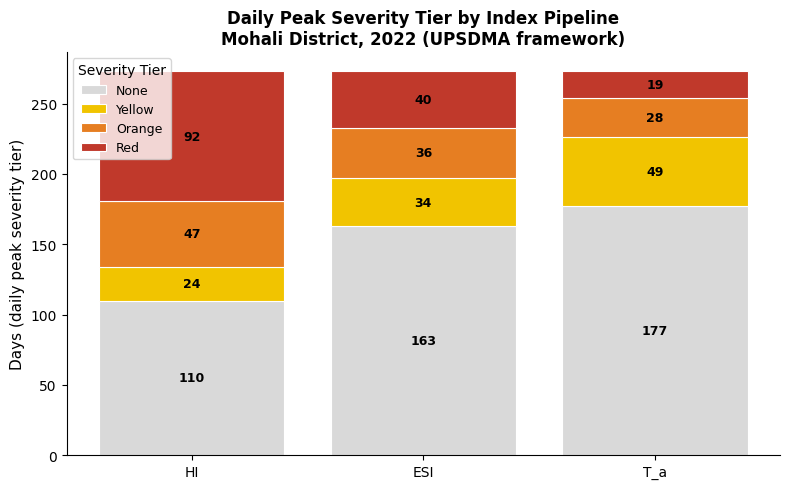

  Saved: fig1_severity_tier_comparison.png


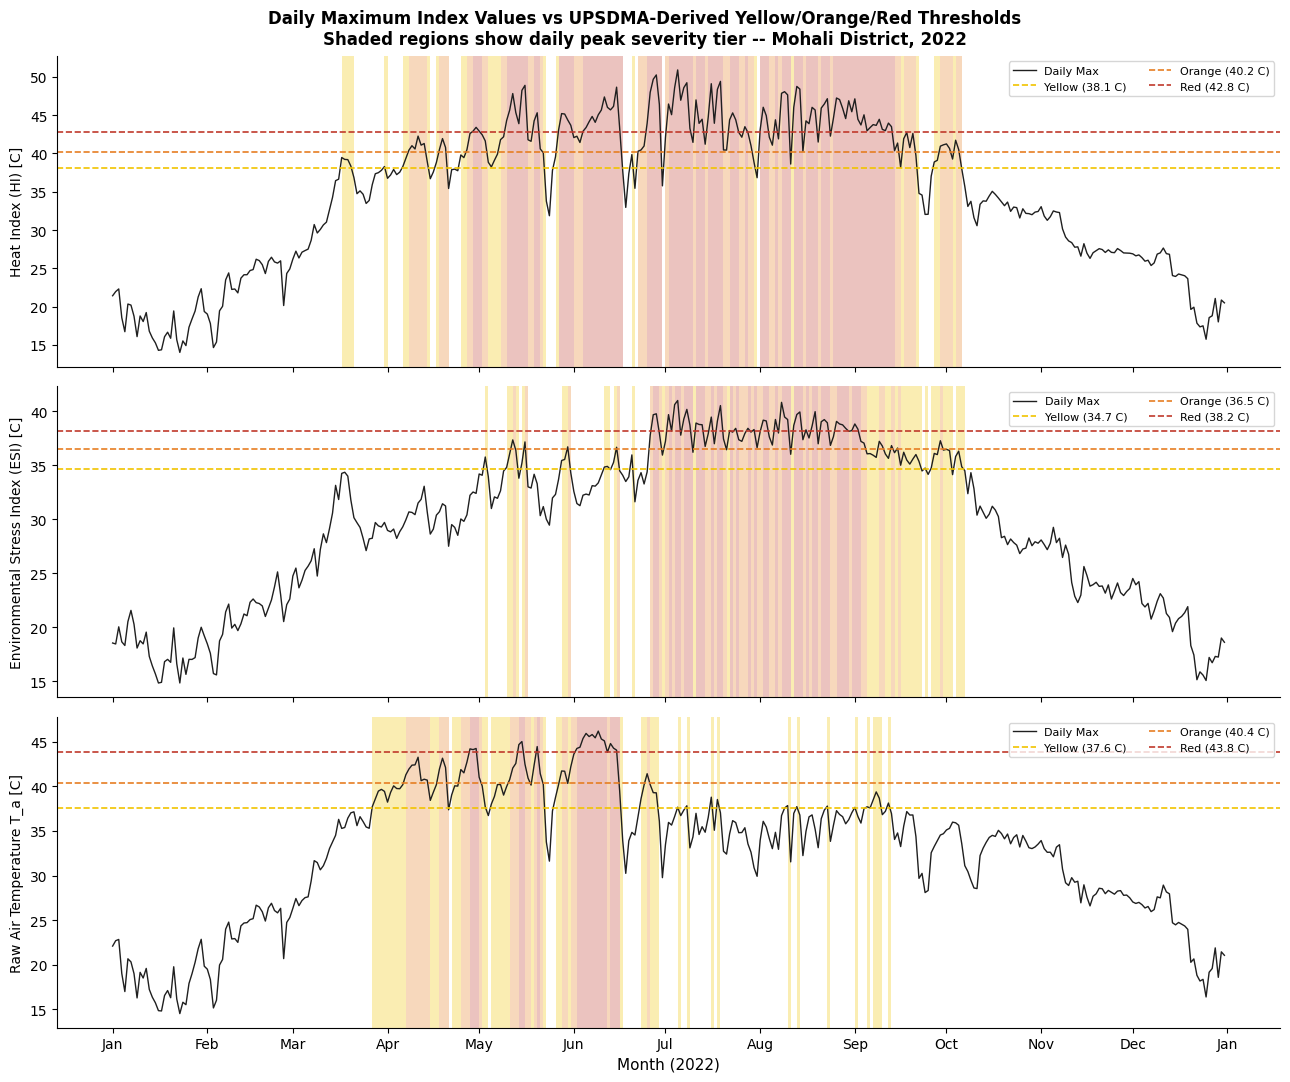

  Saved: fig2_index_time_series_tiers.png


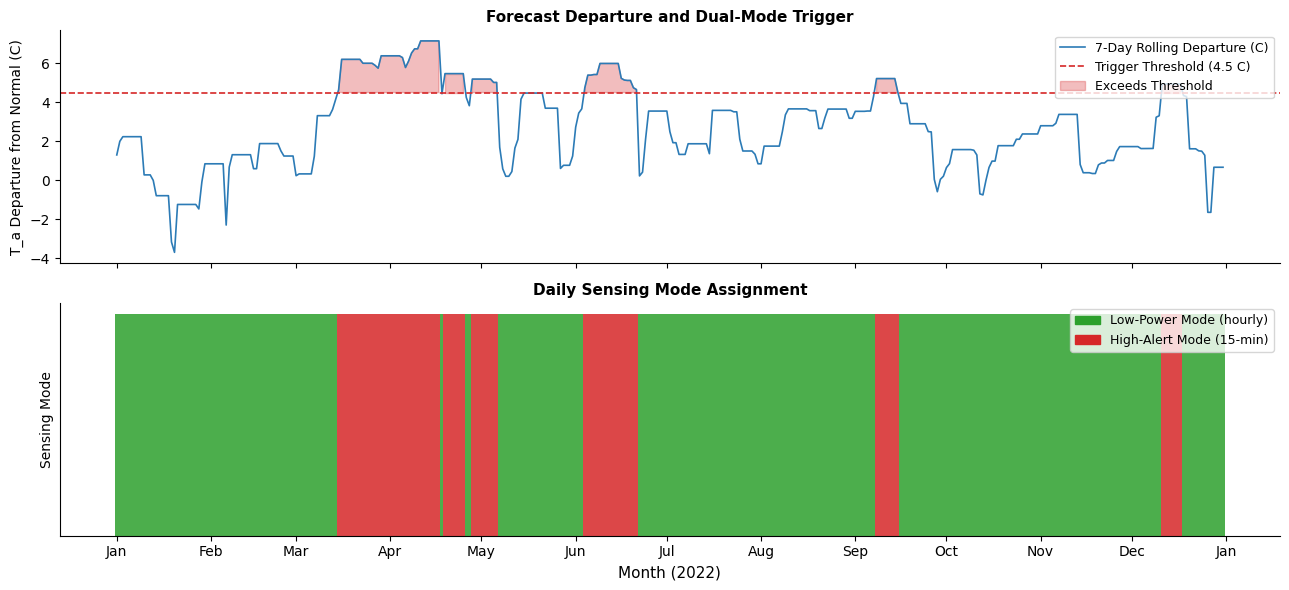

  Saved: fig3_dual_mode_timeline.png


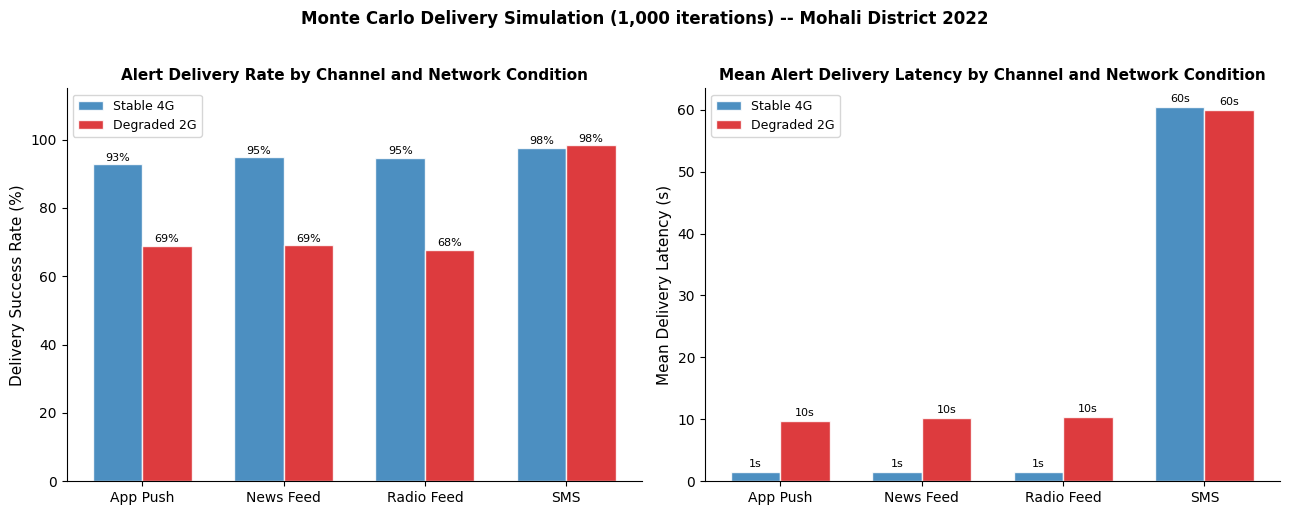

  Saved: fig4_delivery_simulation.png

  All outputs written to: /content/heat_stress_results



In [21]:
def print_table(title: str, df_or_dict):
    width = 72
    print("\n" + "=" * width)
    print(f"  {title}")
    print("=" * width)
    if isinstance(df_or_dict, dict):
        for k, v in df_or_dict.items():
            print(f"  {k:<42} {v}")
    else:
        print(df_or_dict.to_string(index=False))
    print("=" * width)


def run(grib_path, baseline_jan_jun_path, baseline_jul_dec_path, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    print("\n[1/7] Loading ERA5 data...")

    if grib_path and Path(grib_path).exists():
        df_raw = load_era5_grib(grib_path)
    else:
        print("  No GRIB file found -- using synthetic ERA5-like data.")
        df_raw = generate_synthetic_era5()

    print("\n[2/7] Computing heat stress indices...")
    df_idx = compute_indices(df_raw)

    print("\n[3/7] Simulating 25 sensor nodes with UHI offsets...")
    df_nodes = simulate_nodes(df_idx)

    print("\n[4/7] Deriving Yellow/Orange/Red tier thresholds...")
    have_baseline = (baseline_jan_jun_path and baseline_jul_dec_path
                      and Path(baseline_jan_jun_path).exists()
                      and Path(baseline_jul_dec_path).exists())
    if have_baseline:
        df_jan_jun = load_era5_grib(baseline_jan_jun_path, apply_sim_slice=False)
        df_jul_dec = load_era5_grib(baseline_jul_dec_path, apply_sim_slice=False)
        baseline_raw = pd.concat([df_jan_jun, df_jul_dec]).sort_index()
        baseline_idx = compute_indices(baseline_raw)
        tier_thresholds = compute_baseline_tier_thresholds(baseline_idx)
        clim_normal = compute_climatological_normal(baseline_idx)
        print("  T_a: UPSDMA published values (Ludhiana proxy for Mohali)")
        print("  HI/ESI: derived from real ERA5 1991-2020 baseline (11:30-17:30 window)")
    else:
        tier_thresholds = compute_baseline_tier_thresholds()
        clim_normal = None
        print("  T_a: UPSDMA published values (Ludhiana proxy for Mohali)")
        print("  HI/ESI: derived from placeholder baseline -- provide")
        print("  baseline_jan_jun_path/baseline_jul_dec_path for real ERA5 data.")
    for idx_name, tiers in tier_thresholds.items():
        print(f"    {idx_name:>4}:  Yellow={tiers['Yellow']:.2f}   "
              f"Orange={tiers['Orange']:.2f}   Red={tiers['Red']:.2f}")

    print("\n[5/7] Classifying severity tiers...")
    df_alerts = detect_severity_tiers(df_nodes, tier_thresholds)
    df_alerts_heat_season = df_alerts.loc[HEAT_SEASON_START:HEAT_SEASON_END]

    print("\n[6/7] Simulating dual-mode sensor operation...")
    df_mode, mode_daily, forecast = simulate_dual_mode(df_alerts, clim_mean_series=clim_normal)

    print("\n[7/7] Running Monte Carlo delivery simulation...")
    mc_df = monte_carlo_delivery()

    tier_day_summary = summarise_severity_tiers(df_alerts_heat_season)
    print_table("RESULT 1 -- Daily Peak Severity Tier Counts by Index Pipeline", tier_day_summary)

    tier_hour_summary = summarise_severity_hours(df_alerts_heat_season)
    print_table("RESULT 1b -- Hourly Severity Tier Counts by Index Pipeline", tier_hour_summary)

    dual_stats = summarise_dual_mode(mode_daily, forecast)
    print_table("RESULT 2 -- Dual-Mode Sensor Operation Statistics", dual_stats)

    df_mode_alert = df_alerts.copy()
    df_mode_alert["mode"] = df_mode["mode"]
    mode_tier_summary = summarise_severity_by_mode(df_mode_alert)
    print_table("RESULT 3 -- Severity Tier Hours by Sensing Mode", mode_tier_summary)

    print_table("RESULT 4 -- Monte Carlo Alert Delivery Simulation",
                mc_df.sort_values(["Channel", "Network Condition"]))

    tier_day_summary.to_csv(out_dir / "result1_severity_tiers_daily.csv", index=False)
    tier_hour_summary.to_csv(out_dir / "result1b_severity_tiers_hourly.csv", index=False)
    pd.DataFrame([dual_stats]).to_csv(out_dir / "result2_dual_mode.csv", index=False)
    mode_tier_summary.to_csv(out_dir / "result3_severity_by_mode.csv", index=False)
    mc_df.to_csv(out_dir / "result4_delivery.csv", index=False)
    print(f"\n  CSV results saved to: {out_dir}")

    print("\n  Generating figures...")
    plot_severity_tier_comparison(tier_day_summary, out_dir)
    plot_index_time_series_tiers(df_alerts, tier_thresholds, out_dir)
    plot_dual_mode_timeline(mode_daily, forecast, out_dir)
    plot_delivery_results(mc_df, out_dir)

    print(f"\n  All outputs written to: {out_dir}\n")
    return tier_day_summary, tier_hour_summary, dual_stats, mode_tier_summary, mc_df, df_alerts, tier_thresholds


(tier_day_summary, tier_hour_summary, dual_stats,
 mode_tier_summary, mc_df, df_alerts, tier_thresholds) = run(
    grib_path=GRIB_PATH,
    baseline_jan_jun_path=BASELINE_JAN_JUN_PATH,
    baseline_jul_dec_path=BASELINE_JUL_DEC_PATH,
    out_dir=OUT_DIR,
)

## 13. (Optional) Download results as a zip

Starting EDA for meteorological data...
  Loading GRIB: /content/Mohali2022New.grib
  Variables in file (primary load): ['d2m', 't2m']
  Loaded T_a from 't2m'
  Loaded Td from 'd2m'
  SSRD: interpolating 1 missing hour(s)
  Loaded SSRD: mean=57.7 W/m^2, max=1005.8 W/m^2
  Loaded 8,760 records (2022-01-01 00:00:00 to 2022-12-31 23:00:00)

--- Data Head ---
                          T_a        Td        SSRD         RH        HI  \
time                                                                       
2022-01-01 00:00:00  6.574982  4.313019    0.000000  85.476433  5.519920   
2022-01-01 01:00:00  6.338531  4.028107    0.000000  85.160828  5.251584   
2022-01-01 02:00:00  6.308136  3.843048    0.320000  84.237434  5.194039   
2022-01-01 03:00:00  6.511139  3.878326   79.768889  83.274612  5.392200   
2022-01-01 04:00:00  8.687225  5.214264  170.968889  78.815819  7.669473   

                          ESI  
time                           
2022-01-01 00:00:00  3.468006  
2022-01-01 01

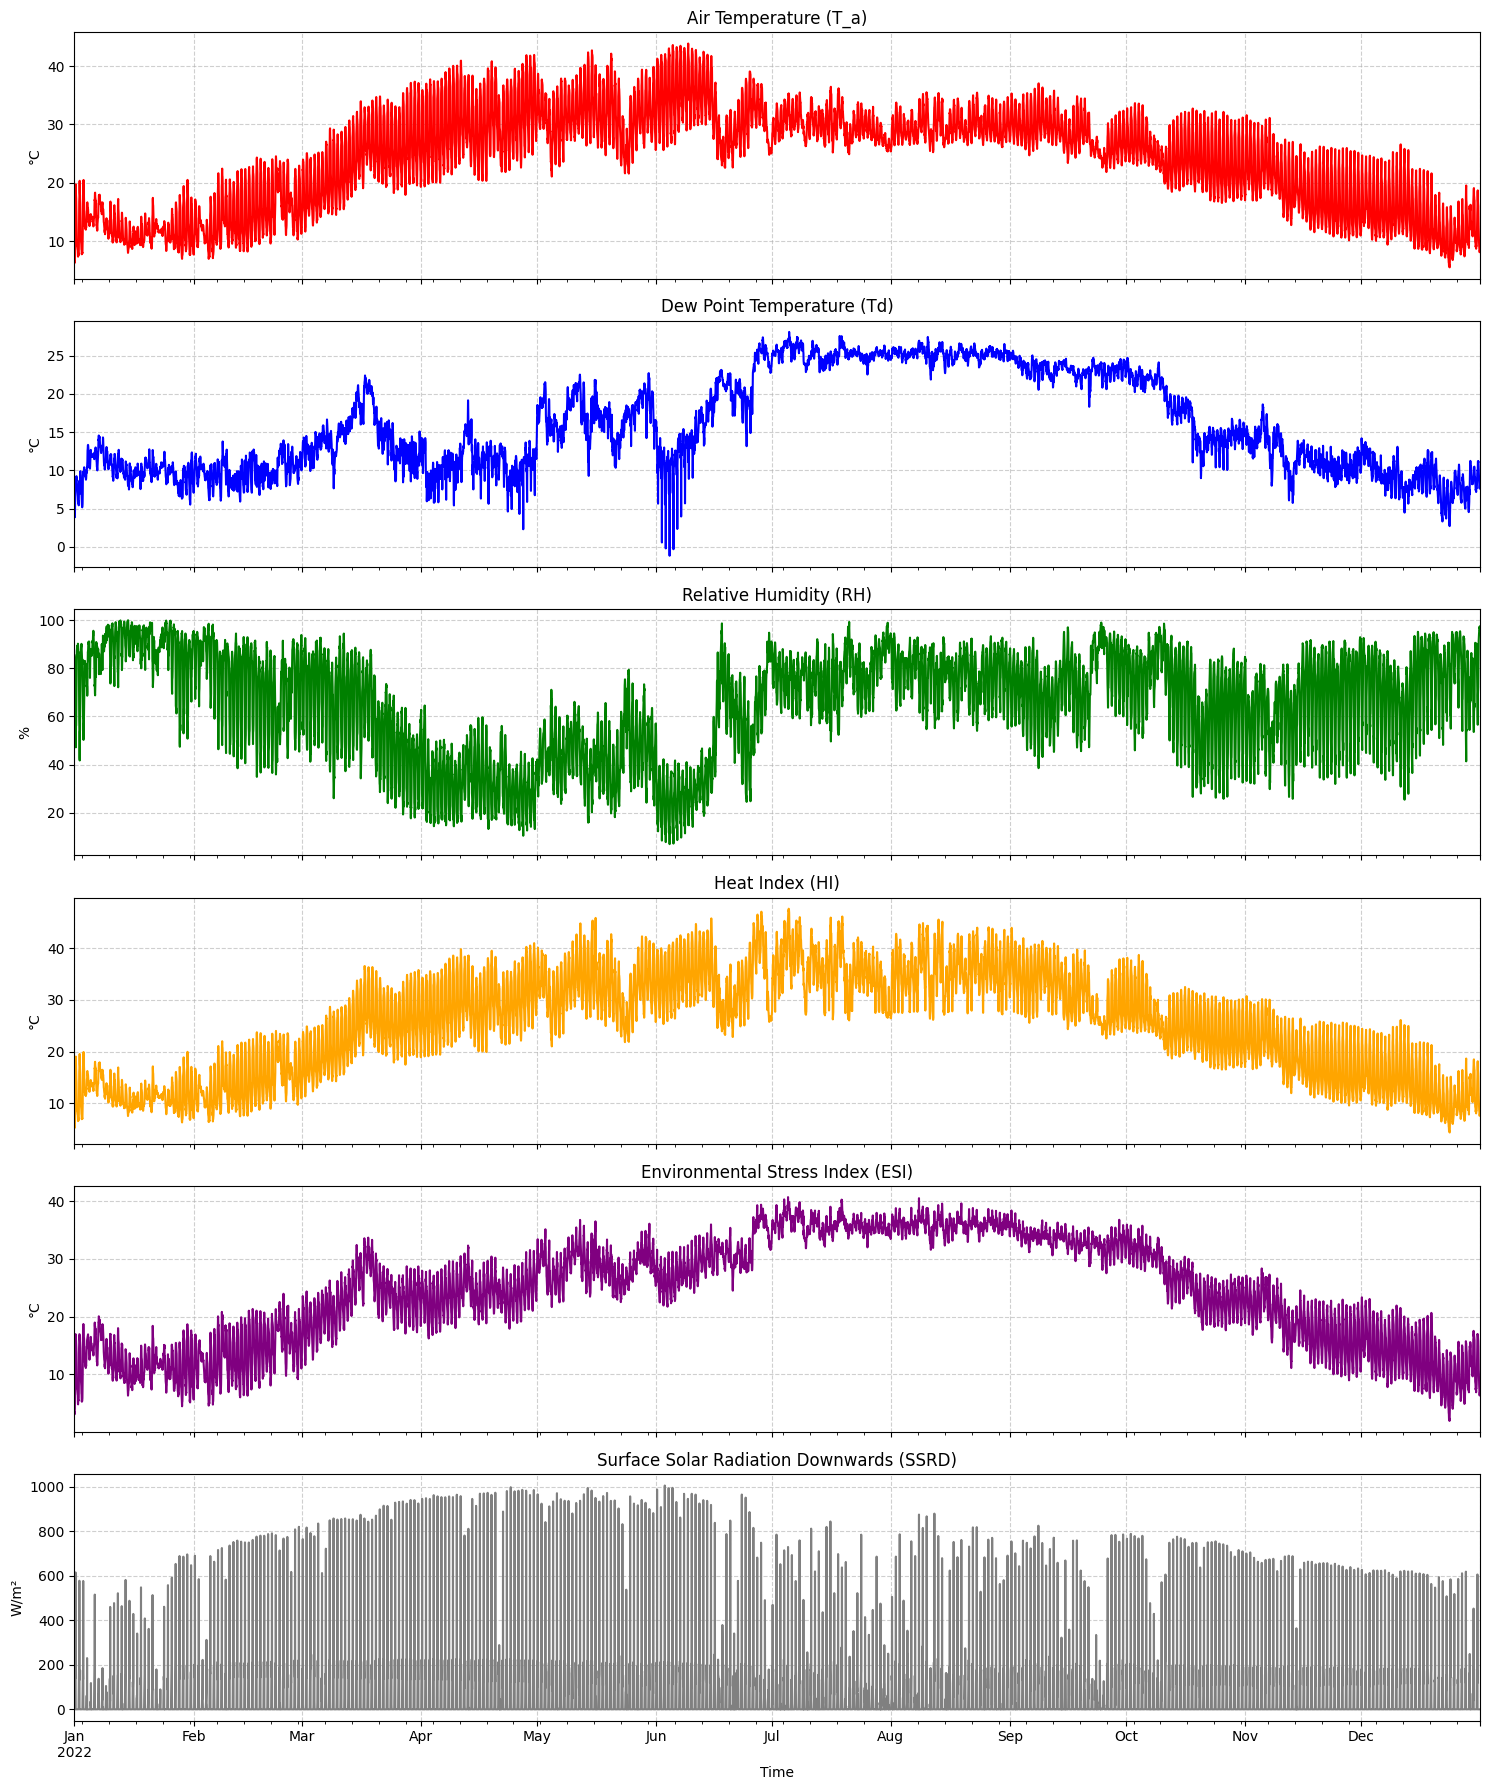

EDA complete. You can now explore the plots and statistics above.


In [20]:
import zipfile
import os
from google.colab import files as colab_files # Re-import for clarity, though likely global

GRIB_PATH = '/content/Mohali2022New.grib'

print("Starting EDA for meteorological data...")

# Load the ERA5 data (will use GRIB_PATH if set, otherwise synthetic)
if GRIB_PATH and Path(GRIB_PATH).exists():
    df_eda = load_era5_grib(GRIB_PATH)
else:
    print("No GRIB file found (or path invalid) -- using synthetic ERA5-like data for EDA.")
    df_eda = generate_synthetic_era5()

# Compute heat stress indices
df_eda = compute_indices(df_eda);

print("\n--- Data Head ---")
print(df_eda.head())

print("\n--- Data Info ---")
df_eda.info()

print("\n--- Data Description ---")
print(df_eda.describe())

# Plot key meteorological variables
print("\nGenerating initial plots...")
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(15, 18), sharex=True)

df_eda['T_a'].plot(ax=axes[0], title='Air Temperature (T_a)', ylabel='°C', color='red')
df_eda['Td'].plot(ax=axes[1], title='Dew Point Temperature (Td)', ylabel='°C', color='blue')
df_eda['RH'].plot(ax=axes[2], title='Relative Humidity (RH)', ylabel='%', color='green')
df_eda['HI'].plot(ax=axes[3], title='Heat Index (HI)', ylabel='°C', color='orange')
df_eda['ESI'].plot(ax=axes[4], title='Environmental Stress Index (ESI)', ylabel='°C', color='purple')
df_eda['SSRD'].plot(ax=axes[5], title='Surface Solar Radiation Downwards (SSRD)', ylabel='W/m²', color='gray')

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlabel('') # Remove x-label from intermediate plots

plt.xlabel('Time')
plt.tight_layout()
plt.show()
print("EDA complete. You can now explore the plots and statistics above.")


In [ ]:
import xarray as xr

grib_path = GRIB_PATH # Use the global GRIB_PATH

ds_check = xr.open_dataset(
    grib_path, engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"paramId": 169}}  # 169 = ssrd in ECMWF table 128
)
print(list(ds_check.data_vars))

In [ ]:
import shutil
from google.colab import files as colab_files

zip_path = shutil.make_archive("/content/heat_stress_results", "zip", OUT_DIR)
colab_files.download(zip_path)